### Ο Αλγόριθμος Naive Bayes: Βασικές Αρχές

Ο Naive Bayes είναι ένας αλγόριθμος ταξινόμησης βασισμένος στο **θεώρημα του Bayes**, με μια "αφελή" (naive) παραδοχή: την **ανεξαρτησία των χαρακτηριστικών**. Δηλαδή, υποθέτει ότι η παρουσία ενός συγκεκριμένου χαρακτηριστικού σε μια κλάση δεν σχετίζεται με την παρουσία οποιουδήποτε άλλου χαρακτηριστικού.

**Πώς λειτουργεί;**

1.  **Θεώρημα του Bayes**: Ο πυρήνας του αλγορίθμου είναι το θεώρημα του Bayes, το οποίο υπολογίζει την πιθανότητα ενός γεγονότος A δεδομένου ενός γεγονότος B, ως εξής:
    `P(A|B) = [P(B|A) * P(A)] / P(B)`
    *   `P(A|B)`: Η εκ των υστέρων πιθανότητα (Posterior Probability) - η πιθανότητα το γεγονός A να συμβεί, δεδομένου ότι το B έχει συμβεί.
    *   `P(B|A)`: Η πιθανότητα (Likelihood) - η πιθανότητα το γεγονός B να συμβεί, δεδομένου ότι το A έχει συμβεί.
    *   `P(A)`: Η εκ των προτέρων πιθανότητα (Prior Probability) - η πιθανότητα το γεγονός A να συμβεί, ανεξάρτητα από το B.
    *   `P(B)`: Η πιθανότητα του γεγονότος B.

2.  **Εφαρμογή στην Ταξινόμηση**: Στην ταξινόμηση, θέλουμε να βρούμε την πιθανότητα μια παρατήρηση `X` να ανήκει σε μια συγκεκριμένη κλάση `C`, δηλαδή `P(C|X)`. Το `X` είναι ένα διάνυσμα χαρακτηριστικών `(x1, x2, ..., xn)`.

    Χρησιμοποιώντας το θεώρημα του Bayes:
    `P(C|x1, ..., xn) = [P(x1, ..., xn | C) * P(C)] / P(x1, ..., xn)`

3.  **Η "Αφελής" Παραδοχή**: Εδώ έρχεται η απλοποίηση. Ο Naive Bayes υποθέτει ότι τα χαρακτηριστικά είναι ανεξάρτητα μεταξύ τους, δεδομένης της κλάσης. Αυτό σημαίνει ότι:
    `P(x1, ..., xn | C) = P(x1|C) * P(x2|C) * ... * P(xn|C)`

    Έτσι, ο τύπος γίνεται:
    `P(C|x1, ..., xn) = [P(x1|C) * P(x2|C) * ... * P(xn|C) * P(C)] / P(x1, ..., xn)`

4.  **Λήψη Απόφασης**: Ο παρονομαστής `P(x1, ..., xn)` είναι σταθερός για όλες τις κλάσεις. Επομένως, για να ταξινομήσουμε μια παρατήρηση, απλώς υπολογίζουμε τον αριθμητή για κάθε δυνατή κλάση και επιλέγουμε την κλάση με τη μεγαλύτερη πιθανότητα.

**Πλεονεκτήματα:**
*   Εύκολος στην υλοποίηση και γρήγορος.
*   Λειτουργεί καλά με μεγάλα σύνολα δεδομένων.
*   Αποτελεσματικός σε προβλήματα ταξινόμησης κειμένου.

**Μειονεκτήματα:**
*   Η "αφελής" παραδοχή ανεξαρτησίας σπάνια ισχύει στην πραγματικότητα, κάτι που μπορεί να επηρεάσει την ακρίβεια των προβλέψεων πιθανότητας (αν και η τελική ταξινόμηση μπορεί να παραμένει καλή).

Υπάρχουν διάφορες παραλλαγές του Naive Bayes (όπως Multinomial, Gaussian, Bernoulli) που διαφέρουν στον τρόπο που υπολογίζουν τις πιθανότητες `P(xi|C)` ανάλογα με τον τύπο των χαρακτηριστικών.

### Περιγραφή Προβλήματος και Φόρτωση του Dataset (Car Theft)

**Πρόβλημα**: Ο στόχος είναι να αναπτύξουμε ένα μοντέλο μηχανικής μάθησης που θα μπορεί να **προβλέπει αν ένα αυτοκίνητο κινδυνεύει να κλαπεί** (Stolen: Yes/No).

**Dataset**: Το σύνολο δεδομένων περιέχει πληροφορίες για διάφορα αυτοκίνητα, με κάθε γραμμή να αντιπροσωπεύει ένα αυτοκίνητο και τις ακόλουθες ιδιότητές του:
*   `Color` (Χρώμα): Το χρώμα του αυτοκινήτου (π.χ., Κόκκινο, Κίτρινο).
*   `Type` (Τύπος): Ο τύπος του οχήματος (π.χ., Sports, Sedan, SUV).
*   `Origin` (Προέλευση): Η χώρα κατασκευής ή προέλευσης του αυτοκινήτου (π.χ., Domestic, Imported).

**Κλάση Εξόδου (Target Variable)**:
*   `Stolen` (Κλαπέν): Η μεταβλητή που θέλουμε να προβλέψουμε, υποδεικνύοντας αν το αυτοκίνητο κλάπηκε (Yes) ή όχι (No).

### Φόρτωση του δεδομένου Dataset (Car Theft)

Θα δημιουργήσουμε ένα Pandas DataFrame.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Δεδομένα που παρείχατε (τώρα με 15 παρατηρήσεις)
data = {
    'Color': ['Red', 'Yellow', 'Red', 'Yellow', 'Red', 'Red', 'Yellow', 'Red', 'Red', 'Yellow', 'Red', 'Red', 'Red', 'Yellow', 'Red'],
    'Type': ['Sports', 'Sedan', 'Sports', 'Sports', 'Sedan', 'SUV', 'Sedan', 'SUV', 'Sports', 'Sports', 'SUV', 'Sedan', 'Sports', 'SUV', 'Sedan'],
    'Origin': ['Domestic', 'Imported', 'Domestic', 'Domestic', 'Imported', 'Imported', 'Imported', 'Imported', 'Imported', 'Domestic', 'Domestic', 'Imported', 'Domestic', 'Imported', 'Domestic'],
    'Stolen': ['Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'No']
}
df_theft = pd.DataFrame(data)

print("Το dataset 'Car Theft' φορτώθηκε επιτυχώς.")
display(df_theft)

Το dataset 'Car Theft' φορτώθηκε επιτυχώς.


,Color,Type,Origin,Stolen
0,Red,Sports,Domestic,Yes
1,Yellow,Sedan,Imported,No
2,Red,Sports,Domestic,Yes
3,Yellow,Sports,Domestic,Yes
4,Red,Sedan,Imported,Yes
5,Red,SUV,Imported,No
6,Yellow,Sedan,Imported,Yes
7,Red,SUV,Imported,No
8,Red,Sports,Imported,Yes
9,Yellow,Sports,Domestic,No


### Προεπεξεργασία Δεδομένων (Data Preprocessing)

Μετατρέπουμε τα κατηγορικά δεδομένα σε αριθμητικές τιμές χρησιμοποιώντας **Label Encoding**.

In [ ]:
# Δημιουργία αντικειμένων LabelEncoder για κάθε κατηγορική στήλη
encoders_theft = {}
for column in df_theft.columns:
    le = LabelEncoder()
    df_theft[column] = le.fit_transform(df_theft[column])
    encoders_theft[column] = le

# Διαχωρισμός χαρακτηριστικών (X) και κλάσης εξόδου (y)
X_theft = df_theft.drop('Stolen', axis=1) # Τα χαρακτηριστικά είναι όλες οι στήλες εκτός της 'Stolen'
y_theft = df_theft['Stolen']             # Η κλάση εξόδου είναι η στήλη 'Stolen'

print("\nΠρώτες 5 γραμμές του προεπεξεργασμένου dataset:")
display(df_theft.head())


Πρώτες 5 γραμμές του προεπεξεργασμένου dataset:


,Color,Type,Origin,Stolen
0,0,2,0,1
1,1,1,1,0
2,0,2,0,1
3,1,2,0,1
4,0,1,1,1


### Διαχωρισμός Δεδομένων σε Training και Testing Sets

Διαχωρίζουμε τα δεδομένα για εκπαίδευση και αξιολόγηση. Λόγω του πολύ μικρού μεγέθους του dataset, ο διαχωρισμός μπορεί να επηρεάσει σημαντικά τα αποτελέσματα.

In [ ]:
# Διαχωρισμός του dataset σε training set και testing set
# Θα χρησιμοποιήσουμε test_size=0.3 (30%) για αυτό το μικρό dataset
# 'random_state' εξασφαλίζει την αναπαραγωγιμότητα
X_train_theft, X_test_theft, y_train_theft, y_test_theft = train_test_split(X_theft, y_theft, test_size=0.3, random_state= 42)

print(f"\nΜέγεθος Training Set (χαρακτηριστικά): {X_train_theft.shape}")
print(f"Μέγεθος Testing Set (χαρακτηριστικά): {X_test_theft.shape}")
print(f"Μέγεθος Training Set (ετικέτες): {y_train_theft.shape}")
print(f"Μέγεθος Testing Set (ετικέτες): {y_test_theft.shape}")

print("\nX_train_theft:")
display(X_train_theft)
print("\ny_train_theft:")
display(y_train_theft)
print("\nX_test_theft:")
display(X_test_theft)
print("\ny_test_theft:")
display(y_test_theft)


Μέγεθος Training Set (χαρακτηριστικά): (10, 3)
Μέγεθος Testing Set (χαρακτηριστικά): (5, 3)
Μέγεθος Training Set (ετικέτες): (10,)
Μέγεθος Testing Set (ετικέτες): (5,)

X_train_theft:


,Color,Type,Origin
8,0,2,1
2,0,2,0
1,1,1,1
14,0,1,0
4,0,1,1
7,0,0,1
10,0,0,0
12,0,2,0
3,1,2,0
6,1,1,1



y_train_theft:


,Stolen
8,1
2,1
1,0
14,0
4,1
7,0
10,0
12,0
3,1
6,1



X_test_theft:


,Color,Type,Origin
9,1,2,0
11,0,1,1
0,0,2,0
13,1,0,1
5,0,0,1



y_test_theft:


,Stolen
9,0
11,1
0,1
13,0
5,0


### Εκπαίδευση του Μοντέλου Naive Bayes

Εκπαιδεύουμε τον **Multinomial Naive Bayes** ταξινομητή με τα προεπεξεργασμένα δεδομένα.

In [ ]:
# Αρχικοποίηση του Multinomial Naive Bayes ταξινομητή
model_theft = MultinomialNB()

# Εκπαίδευση του μοντέλου
model_theft.fit(X_train_theft, y_train_theft)

print("Το μοντέλο Naive Bayes εκπαιδεύτηκε επιτυχώς στο dataset 'Car Theft'.")

Το μοντέλο Naive Bayes εκπαιδεύτηκε επιτυχώς στο dataset 'Car Theft'.


### Αξιολόγηση του Μοντέλου

Αξιολογούμε την απόδοση του μοντέλου χρησιμοποιώντας τις γνωστές μετρικές.

[1 0 1 0 0]

Ακρίβεια του μοντέλου: 0.60

Μετρικές ανά κλάση:
  Κλάση 'No': Precision=0.67, Recall=0.67
  Κλάση 'Yes': Precision=0.50, Recall=0.50


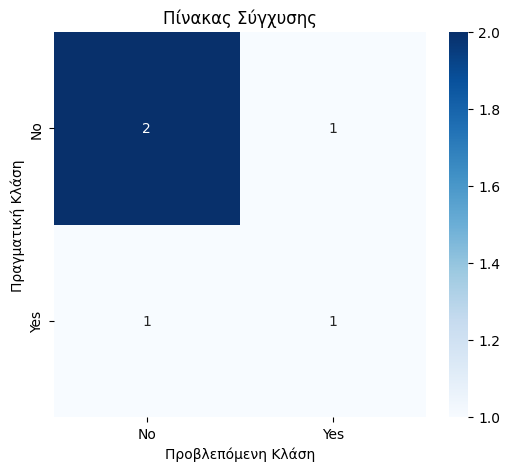

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

# Κάνουμε προβλέψεις στο testing set
y_pred_theft = model_theft.predict(X_test_theft)
print(y_pred_theft)

# Υπολογισμός της ακρίβειας
accuracy_theft = accuracy_score(y_test_theft, y_pred_theft)
print(f"\nΑκρίβεια του μοντέλου: {accuracy_theft:.2f}")

# Υπολογισμός της Precision και Recall
# zero_division=0 ορίζει ότι όταν υπάρχει διαίρεση με το μηδέν (π.χ. καμία πρόβλεψη για μια κλάση), η τιμή να είναι 0
precision_theft = precision_score(y_test_theft, y_pred_theft, average=None, zero_division=0)
recall_theft = recall_score(y_test_theft, y_pred_theft, average=None, zero_division=0)

target_names_theft = encoders_theft['Stolen'].inverse_transform(sorted(y_theft.unique()))

print("\nΜετρικές ανά κλάση:")
for i, name in enumerate(target_names_theft):
    print(f"  Κλάση '{name}': Precision={precision_theft[i]:.2f}, Recall={recall_theft[i]:.2f}")

# Υπολογισμός και εμφάνιση του Πίνακα Σύγχυσης
conf_matrix_theft = confusion_matrix(y_test_theft, y_pred_theft)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_theft, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_theft, yticklabels=target_names_theft)
plt.xlabel('Προβλεπόμενη Κλάση')
plt.ylabel('Πραγματική Κλάση')
plt.title('Πίνακας Σύγχυσης')
plt.show()